> **Data required:** This notebook uses InSight HP³ data from Spohn et al. (2024). 
> If you haven't already, download the datasets from [FigShare](https://doi.org/10.6084/m9.figshare.25099754) 
> and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.

In [1]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 1e-7       # thermal diffusivity [m^2/s]
z_min = 0             # surface
z_max = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

R_mole = 0.0135       # Radius of the mole
r_max = 0.25          # Max distance from mole center

z_0 = 0.017           # Top of mole
z_1 = 0.363           # bottom of mole

avg_bottom_temp = 225.6  # average bottom temperature (K)


# Import fourier coefficients for amalytical solutions at the boundaries

import pickle

with open('../resources/data/fourier_coefficients.pkl', 'rb') as f:
    coeffs = pickle.load(f)


# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


key = random.PRNGKey(0)
key, key1, key2, key3, key4, key5, key6 = random.split(key, 7)

#-------- 1. Boundary Condition points used for Perturbation network --------
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0). No perturbation on the surface temperature.:

t_bc_surface = random.uniform(key2, (n_surface, 1), minval=0, maxval=sol_seconds) # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))
r_bc_surface = random.uniform(key3, (n_surface, 1), minval=R_mole, maxval=r_max)

u_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = random.uniform(key5, (n_surface, 1), minval=0, maxval=sol_seconds) # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * z_max
r_bc_bottom = random.uniform(key4, (n_surface, 1), minval=R_mole, maxval=r_max)

u_bc_bottom = jnp.zeros((n_surface, 1))  # (552, 1)


# Mole surface boundary (r = r_mole)

N_z_mole = 20
N_t_mole = len(ltst_mole)

z_mole_1d = jnp.linspace(z_0, z_1, N_z_mole)
t_mole_1d = jnp.array(ltst_mole)

Z_mole, T_mole_grid = jnp.meshgrid(z_mole_1d, t_mole_1d, indexing='ij')
# Z_mole shape: (20, 200), T_mole_grid shape: (20, 200)

x_bc_mole = Z_mole.flatten().reshape(-1, 1)        # (4000, 1)
t_bc_mole = T_mole_grid.flatten().reshape(-1, 1)    # (4000, 1)
r_bc_mole = jnp.ones_like(x_bc_mole) * R_mole       # (4000, 1)

# Temperature: T_mole depends only on t, not z (isothermal)
# Need to repeat temp_mole for each z point
temp_mole_arr = jnp.array(temp_mole)  # (200,)
u_bc_mole = jnp.tile(temp_mole_arr, N_z_mole).reshape(-1, 1)  # (4000, 1)

# Rmax boundary

key1, key7, key8 = random.split(key1, 3)
n_far = 2000

t_bc_far = random.uniform(key7, (n_far, 1), minval=0, maxval=sol_seconds)
x_bc_far = random.uniform(key8, (n_far, 1), minval=0, maxval=z_max)
r_bc_far = jnp.ones((n_far, 1)) * r_max
u_bc_far = jnp.zeros((n_far, 1))  


#Join all bcs except the mole surface

t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom, t_bc_far])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom, x_bc_far])
r_bc = jnp.concatenate([r_bc_surface, r_bc_bottom, r_bc_far])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom, u_bc_far])

# 2. Physics collocation points (30 * 30 * 30 = 9000 points)
t_physics = random.uniform(key1, (9000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (9000, 1), minval=0, maxval=z_max)
r_physics = random.uniform(key6, (9000, 1), minval=R_mole, maxval=r_max)



# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, z_max
r_min, r_norm_max = R_mole, r_max
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_r(r): return ( r - r_min) / (r_norm_max - r_min)


# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
r_bc = normalize_r(r_bc)
#u_bc = normalize_u(u_bc)

t_bc_mole_norm = normalize_t(t_bc_mole)
x_bc_mole_norm = normalize_x(x_bc_mole)
r_bc_mole_norm = normalize_r(r_bc_mole)
#u_bc_mole = normalize_u(u_bc_mole)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)
r_physics = normalize_r(r_physics)


# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)
    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, r_point, kappa):

    def u(t_val, x_val, r_val):
        txr_in = jnp.array([[t_val, x_val, r_val]])
        return network(params, txr_in)[0, 0]

    # Derivatives w.r.t. NORMALIZED inputs
    du_dt = grad(u, argnums=0)(t_point, x_point, r_point)
    du_dr = grad(u, argnums=2)(t_point, x_point, r_point)
    d2u_dr2 = grad(grad(u, argnums=2), argnums=2)(t_point, x_point, r_point)
    d2u_dx2 = grad(grad(u, argnums=1), argnums=1)(t_point, x_point, r_point)

    # Scale factors (physical ranges)
    dt = t_max - t_min          # 88775.244
    dz = x_max - x_min          # 0.4
    dr = r_max - R_mole          # 0.2365

    # Physical r from normalized r: r_phys = R_mole + r_norm * Δr
    r_phys = R_mole + r_point * dr

    # PDE residual (divided by κ, your week 8 trick):
    # (1/κ) * (dT_n/dt_n)/Δt - (d²T_n/dr_n²)/Δr² - (1/r_phys)*(dT_n/dr_n)/Δr - (d²T_n/dz_n²)/Δz²

    kappa_dt = kappa * dt
    residual = (du_dt  - (d2u_dr2 / dr**2) * kappa_dt - ((1.0 / r_phys) * du_dr / dr) * kappa_dt - kappa_dt * (d2u_dx2 / dz**2))

    return residual

physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, 0, None))

# Solve every point Analytacly using the Fourier series solution for the undisturbed soil temperature. 
def T_1D(A_n, phi_n, T_mean, N_harmonics, omega):
    """undisturbed soil temperature - Fourier Series"""
    n_vals = jnp.arange(1, N_harmonics + 1)
    An = A_n[1:N_harmonics + 1]
    phin = phi_n[1:N_harmonics + 1]

    @jit
    def T_analytical(t, z, kappa):
        # Skin depths recomputed each call using current kappa
        delta_n = jnp.sqrt(2 * kappa / (n_vals * omega))
        u_far = T_mean + jnp.sum(
            An * jnp.exp(-z / delta_n) * jnp.cos(n_vals * omega * t - z / delta_n + phin)
        )

        return u_far

    return T_analytical


# Vectorize to handle all physics points at once

T_far = T_1D(
    jnp.array(coeffs['A_n']),
    jnp.array(coeffs['phi_n']),
    coeffs['T_mean'],
    coeffs['N_harmonics'],
    coeffs['omega']
)

T_sol_batch = vmap(T_far, in_axes=(0, 0, None))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [3, 64, 64, 64, 1]  # 3 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={40000: 0.1, 80000: 0.01})
optimizer = optax.adam(schedule)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, r_bc, u_bc, t_bc_mole, x_bc_mole, u_bc_mole, t_bc_mole_norm, x_bc_mole_norm, r_bc_mole_norm, t_physics, x_physics, r_physics, kappa):

    def loss_fn(params):

        # 1. Boundary Condition Loss. Surface, bottom and far field
        txr_bc = jnp.concatenate([t_bc, x_bc, r_bc], axis=1)

        u_pred_bc = network(params, txr_bc)
        bc_loss_edges = jnp.mean((u_pred_bc - u_bc)**2)

        # Boundary condition at mole surface (r = r_mole)
        u_pred_mole = network(params, jnp.concatenate([t_bc_mole_norm, x_bc_mole_norm, r_bc_mole_norm], axis=1)) 
        target = u_bc_mole - T_sol_batch(t_bc_mole.ravel(), x_bc_mole.ravel(), kappa).reshape(-1, 1)  # Subtract the undisturbed solution to get the perturbation target
        bc_loss_mole = jnp.mean((u_pred_mole - target)**2)  


        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(),
                                                x_physics.ravel(),
                                                r_physics.ravel(),
                                                kappa)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.


        return  bc_loss_edges * 10 + physics_loss + bc_loss_mole * 10, (bc_loss_edges, physics_loss, bc_loss_mole)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 100000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []



# Training loop
losses = []
losses_bc_edges = []
losses_phys = []
losses_bc_mole = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, r_bc, u_bc,
        t_bc_mole, x_bc_mole, u_bc_mole, t_bc_mole_norm, x_bc_mole_norm, r_bc_mole_norm,
        t_physics, x_physics, r_physics,
        kappa
    )

    losses.append(loss)
    losses_bc_edges.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_bc_mole.append(individual_loss[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"BC edges: {individual_loss[0]:.6f}")
        print(f"Physics:  {individual_loss[1]:.6f}")
        print(f"BC mole:  {individual_loss[2]:.6f}")


import pickle

forward_params = params  # your trained forward params
with open('forward_checkpoint/forward_warmstart_1e-7.pkl', 'wb') as f:
    pickle.dump(jax.device_get(forward_params), f)


/mnt/c/ai-in-physics/cfd-ai-journey/.venv-linux/lib/python3.12/site-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/100000, Loss: 40.565010
BC edges: 2.077104
Physics:  3.094238
BC mole:  1.669973
Iteration 2000/100000, Loss: 14.854607
BC edges: 0.769234
Physics:  2.613893
BC mole:  0.454837
Iteration 3000/100000, Loss: 7.510099
BC edges: 0.400432
Physics:  1.205882
BC mole:  0.229990
Iteration 4000/100000, Loss: 4.993207
BC edges: 0.240886
Physics:  1.124407
BC mole:  0.145994
Iteration 5000/100000, Loss: 3.603315
BC edges: 0.162296
Physics:  0.983167
BC mole:  0.099719
Iteration 6000/100000, Loss: 3.025316
BC edges: 0.122426
Physics:  1.010382
BC mole:  0.079067
Iteration 7000/100000, Loss: 2.449032
BC edges: 0.102050
Physics:  0.790289
BC mole:  0.063824
Iteration 8000/100000, Loss: 1.862938
BC edges: 0.086488
Physics:  0.431456
BC mole:  0.056660
Iteration 9000/100000, Loss: 2.405952
BC edges: 0.121630
Physics:  0.493608
BC mole:  0.069605
Iteration 10000/100000, Loss: 1.749412
BC edges: 0.077016
Physics:  0.485955
BC mole:  0.049330
Iteration 11000/100000, Loss: 1.545652
BC edges

## loss curves

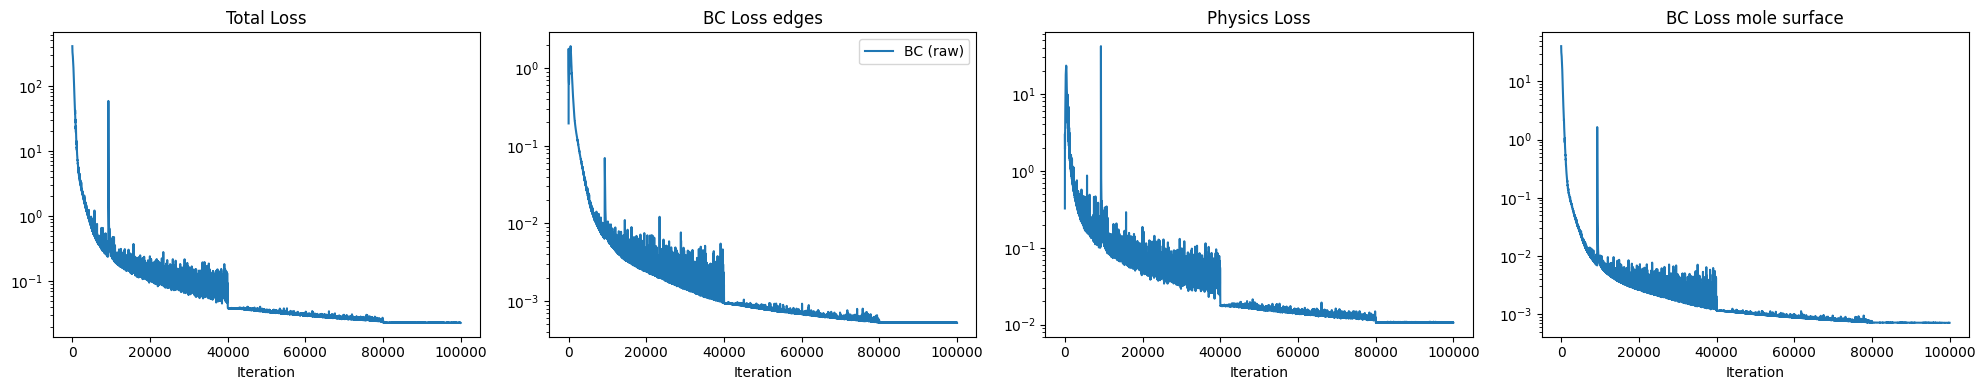


Final BC loss (raw):  5.253085e-04
Final Physics loss:   1.066212e-02


In [19]:
# --- 1. Loss curves (downsampled to every 100th point) ---
step = 10
iters = np.arange(0, len(losses), step)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].semilogy(iters, [float(losses[i]) for i in iters])
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Iteration')

axes[1].semilogy(iters, [float(losses_bc_edges[i]) for i in iters], label='BC (raw)')
#axes[1].semilogy(iters, [50*float(losses_bc_core[i]) for i in iters], label='BC × 50', linestyle='--')
axes[1].set_title('BC Loss edges')
axes[1].legend()
axes[1].set_xlabel('Iteration')

axes[2].semilogy(iters, [float(losses_phys[i]) for i in iters])
axes[2].set_title('Physics Loss')
axes[2].set_xlabel('Iteration')

axes[3].semilogy(iters, [float(losses_bc_mole[i]) for i in iters])
axes[3].set_title('BC Loss mole surface')
axes[3].set_xlabel('Iteration')

plt.tight_layout()
plt.show()

# Print final magnitudes so we can see the balance
print(f"\nFinal BC loss (raw):  {float(losses_bc_edges[-1]):.6e}")
#print(f"Final BC loss (×50):  {50*float(losses_bc_core[-1]):.6e}")
print(f"Final Physics loss:   {float(losses_phys[-1]):.6e}")
#print(f"Ratio physics/BC×50:  {float(losses_phys[-1])/(50*float(losses_bc_core[-1])):.1f}")

## Physics graphs

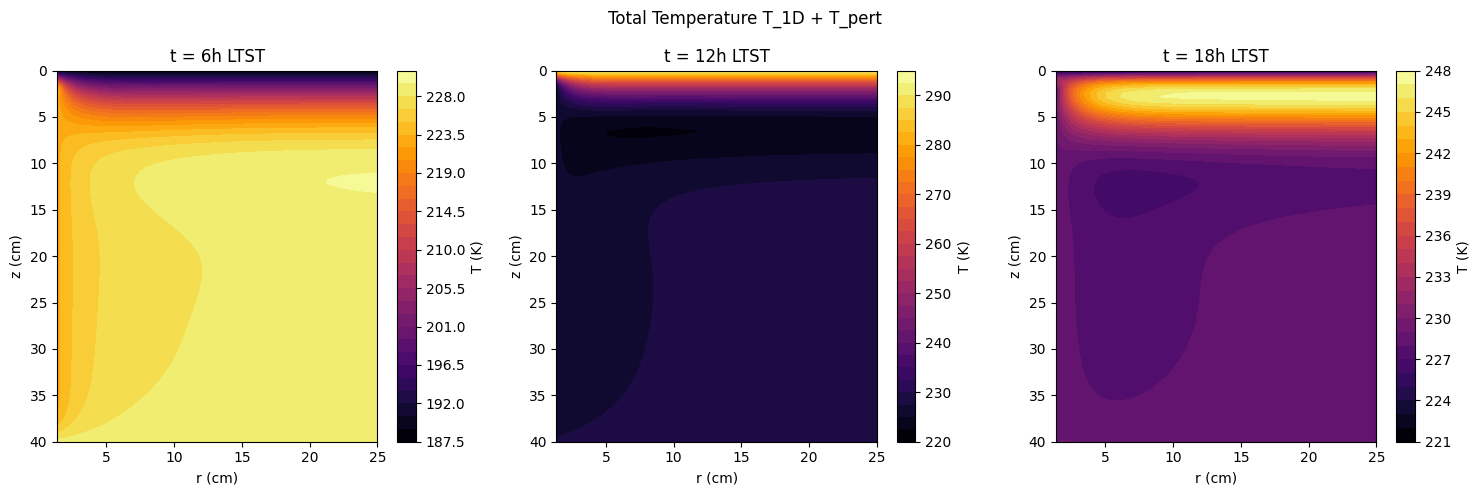

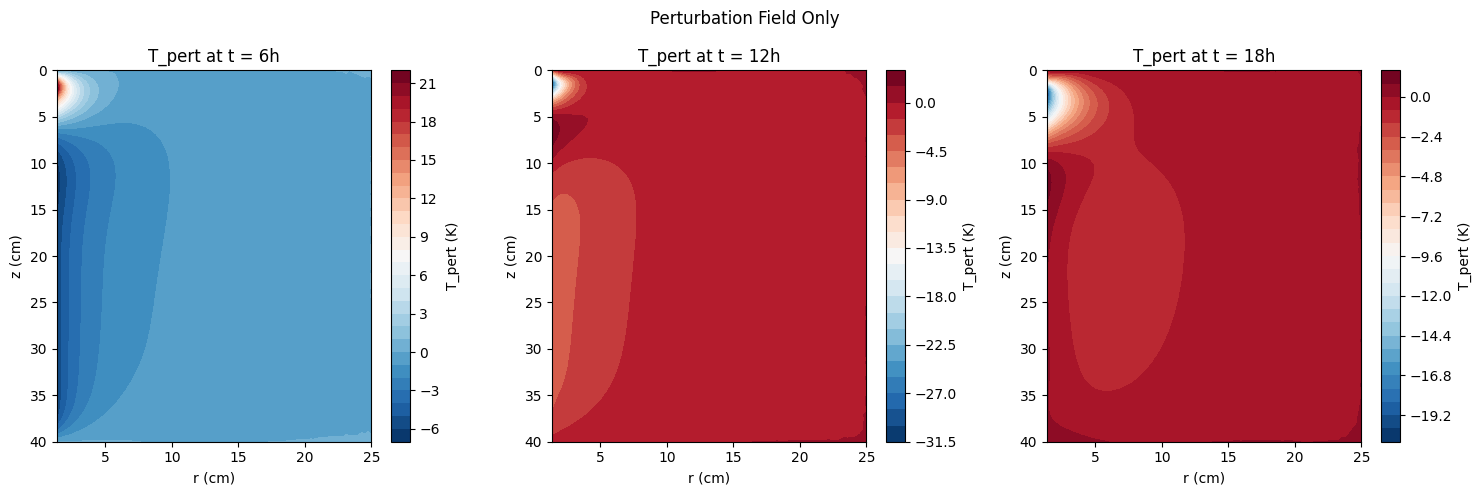

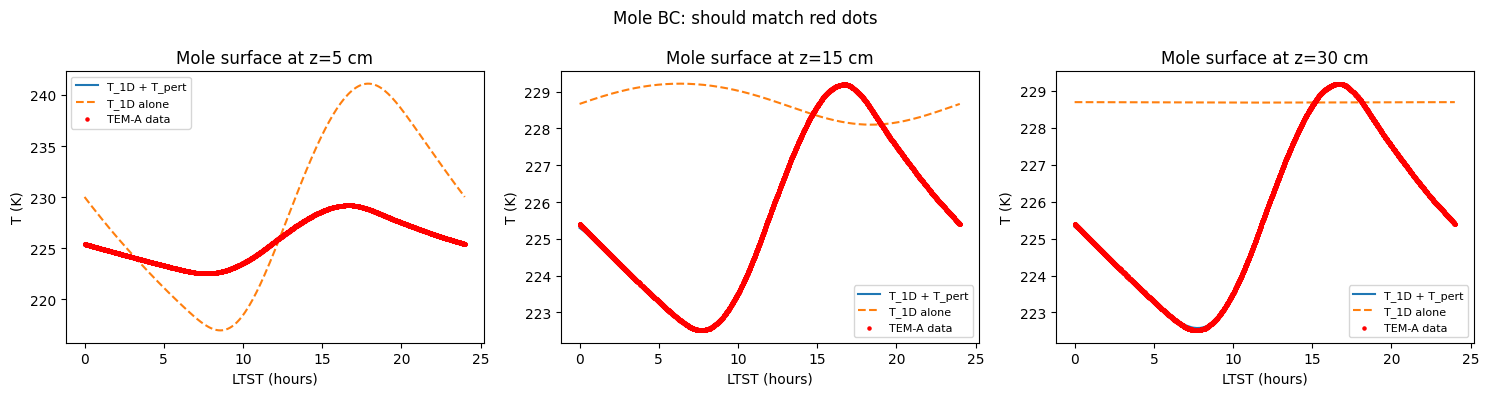

In [20]:
# ---- 1. T_pert field at fixed time slices ----

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
times_hours = [6, 12, 18]  # local times to visualize

r_plot = jnp.linspace(R_mole, r_max, 100)
z_plot = jnp.linspace(0, z_max, 100)
R_grid, Z_grid = jnp.meshgrid(r_plot, z_plot, indexing='ij')  # (100, 100)

for ax, t_hr in zip(axes, times_hours):
    t_sec = t_hr * sol_seconds / 24
    T_grid = jnp.ones_like(R_grid) * t_sec

    # Flatten, normalize, predict
    t_flat = normalize_t(T_grid.flatten().reshape(-1, 1))
    x_flat = normalize_x(Z_grid.flatten().reshape(-1, 1))
    r_flat = normalize_r(R_grid.flatten().reshape(-1, 1))

    inputs = jnp.concatenate([t_flat, x_flat, r_flat], axis=1)
    T_pert = network(params, inputs).reshape(100, 100)

    # T_1D at these points (only depends on z, t)
    T_1d = T_sol_batch(
        T_grid.flatten(), Z_grid.flatten(), kappa
    ).reshape(100, 100)

    T_total = T_1d + T_pert

    im = ax.contourf(R_grid * 100, Z_grid * 100, T_total, levels=30, cmap='inferno')
    ax.set_xlabel('r (cm)')
    ax.set_ylabel('z (cm)')
    ax.set_title(f't = {t_hr}h LTST')
    ax.invert_yaxis()
    plt.colorbar(im, ax=ax, label='T (K)')

plt.suptitle('Total Temperature T_1D + T_pert')
plt.tight_layout()
plt.show()


# ---- 2. T_pert alone (should be nonzero near mole, zero far away) ----

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, t_hr in zip(axes, times_hours):
    t_sec = t_hr * sol_seconds / 24
    T_grid = jnp.ones_like(R_grid) * t_sec

    t_flat = normalize_t(T_grid.flatten().reshape(-1, 1))
    x_flat = normalize_x(Z_grid.flatten().reshape(-1, 1))
    r_flat = normalize_r(R_grid.flatten().reshape(-1, 1))

    inputs = jnp.concatenate([t_flat, x_flat, r_flat], axis=1)
    T_pert = network(params, inputs).reshape(100, 100)

    im = ax.contourf(R_grid * 100, Z_grid * 100, T_pert, levels=30, cmap='RdBu_r')
    ax.set_xlabel('r (cm)')
    ax.set_ylabel('z (cm)')
    ax.set_title(f'T_pert at t = {t_hr}h')
    ax.invert_yaxis()
    plt.colorbar(im, ax=ax, label='T_pert (K)')

plt.suptitle('Perturbation Field Only')
plt.tight_layout()
plt.show()


# ---- 3. Mole surface check: T_total at r=R_mole vs TEM-A data ----

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
z_checks = [0.05, 0.15, 0.30]  # three depths along the mole

t_eval = jnp.linspace(0, sol_seconds, 200)

for ax, z_val in zip(axes, z_checks):
    t_norm = normalize_t(t_eval.reshape(-1, 1))
    x_norm = normalize_x(jnp.ones((200, 1)) * z_val)
    r_norm = normalize_r(jnp.ones((200, 1)) * R_mole)

    inputs = jnp.concatenate([t_norm, x_norm, r_norm], axis=1)
    T_pert_pred = network(params, inputs).ravel()

    T_1d_pred = T_sol_batch(t_eval, jnp.ones(200) * z_val, kappa)
    T_total_pred = T_1d_pred + T_pert_pred

    hours = t_eval * 24 / sol_seconds

    ax.plot(hours, T_total_pred, label='T_1D + T_pert')
    ax.plot(hours, T_1d_pred, '--', label='T_1D alone')
    ax.scatter(jnp.array(ltst_mole) * 24 / sol_seconds,
               temp_mole, s=5, c='red', label='TEM-A data', zorder=5)
    ax.set_xlabel('LTST (hours)')
    ax.set_ylabel('T (K)')
    ax.set_title(f'Mole surface at z={z_val*100:.0f} cm')
    ax.legend(fontsize=8)

plt.suptitle('Mole BC: should match red dots')
plt.tight_layout()
plt.show()

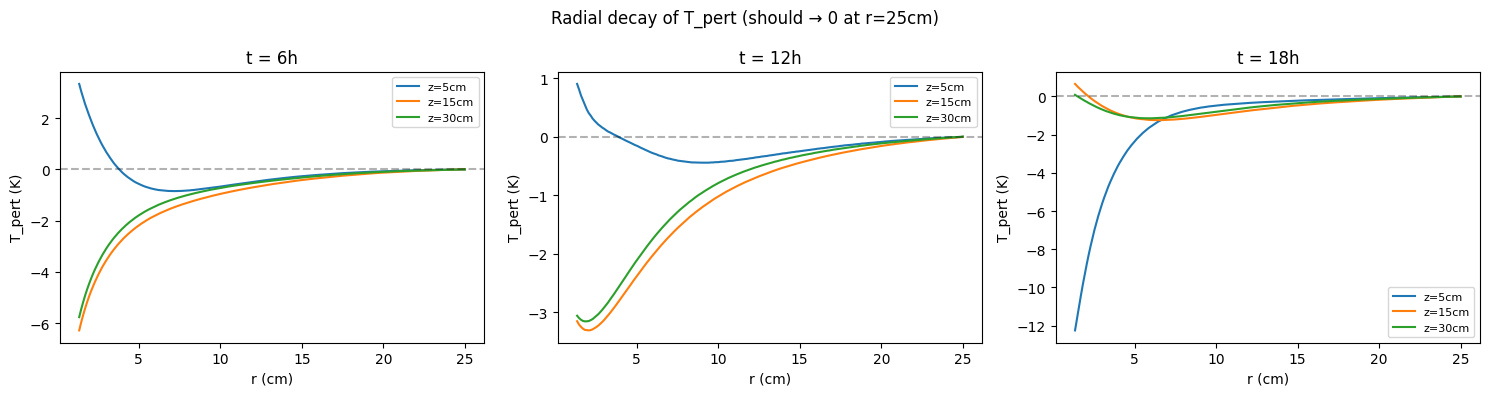

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
times_hours = [6, 12, 18]
z_checks = [0.05, 0.15, 0.30]

r_line = jnp.linspace(R_mole, r_max, 200)

for ax, t_hr in zip(axes, times_hours):
    t_sec = t_hr * sol_seconds / 24
    
    for z_val in z_checks:
        t_norm = normalize_t(jnp.ones((200, 1)) * t_sec)
        x_norm = normalize_x(jnp.ones((200, 1)) * z_val)
        r_norm = normalize_r(r_line.reshape(-1, 1))
        
        inputs = jnp.concatenate([t_norm, x_norm, r_norm], axis=1)
        T_pert = network(params, inputs).ravel()
        
        ax.plot(r_line * 100, T_pert, label=f'z={z_val*100:.0f}cm')
    
    ax.axhline(0, color='k', linestyle='--', alpha=0.3)
    ax.set_xlabel('r (cm)')
    ax.set_ylabel('T_pert (K)')
    ax.set_title(f't = {t_hr}h')
    ax.legend(fontsize=8)

plt.suptitle('Radial decay of T_pert (should → 0 at r=25cm)')
plt.tight_layout()
plt.show()